# Notebook 8: Correlation & Covariance

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What are Covariance and Correlation?

Both measure the **relationship between two variables**: when one changes, does the other change too?

**Analogy:** Study hours and exam marks usually rise together. Screen time and sleep hours usually move in opposite directions. Shoe size and exam marks have no link at all.

**Why it matters in AI/ML:** We use correlation to find useful features (strong link with the target), to remove duplicate features (two features that are almost the same), and to understand the data before building a model.

**Topics covered:** Covariance, Correlation, Positive / Negative / No Correlation, Pearson, Spearman, Correlation Matrix, Heatmap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

## 1. Covariance

**Definition:** Covariance measures the **direction** in which two variables move together.
- Positive: both increase together
- Negative: one increases while the other decreases
- Near zero: no clear linear relationship

**Formula:**

Sample covariance:

$$Cov(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$

Population covariance divides by N instead of n - 1.

**Numerical Example:** Hours studied (X) and marks (Y)

| X | Y | X - mean(X) | Y - mean(Y) | Product |
|---|---|---|---|---|
| 2 | 50 | -4 | -19 | 76 |
| 4 | 60 | -2 | -9 | 18 |
| 6 | 65 | 0 | -4 | 0 |
| 8 | 80 | 2 | 11 | 22 |
| 10 | 90 | 4 | 21 | 84 |

Mean(X) = 6, Mean(Y) = 69, sum of products = 200
Sample covariance = 200 / 4 = **50** (positive, so they move together)

**Business Example:** A retailer checks whether advertising spend and sales rise together.

**AI/ML Example:** The **covariance matrix** is the core of **PCA** (it finds the directions of highest variance) and is used in Gaussian models and portfolio risk.

**Limitation:** The value depends on the units (hours x marks), so "50" is hard to judge as strong or weak. Correlation fixes this.

In [2]:
hours = np.array([2, 4, 6, 8, 10])
marks = np.array([50, 60, 65, 80, 90])

# Manual calculation
cov_manual = np.sum((hours - hours.mean()) * (marks - marks.mean())) / (len(hours) - 1)

# NumPy returns a covariance matrix
cov_matrix = np.cov(hours, marks)

print("Manual sample covariance:", cov_manual)
print("\nCovariance matrix:\n", cov_matrix)
print("\nCov(hours, marks) =", cov_matrix[0, 1])
print("Var(hours) =", cov_matrix[0, 0], "| Var(marks) =", cov_matrix[1, 1])

# Covariance changes with units
marks_out_of_1 = marks / 100
print("\nCov with marks out of 100:", cov_matrix[0, 1])
print("Cov with marks out of 1  :", np.cov(hours, marks_out_of_1)[0, 1])

Manual sample covariance: 50.0

Covariance matrix:
 [[ 10.  50.]
 [ 50. 255.]]

Cov(hours, marks) = 50.0
Var(hours) = 10.0 | Var(marks) = 255.0

Cov with marks out of 100: 50.0
Cov with marks out of 1  : 0.5


**Explanation:** We calculate covariance manually and with `np.cov()`. NumPy returns a 2x2 matrix: the diagonal has the variances, and the off-diagonal has the covariance. Then we change the units of marks to show how covariance changes.

**Interpretation:** Covariance is +50, so more study hours go with higher marks. But when we only changed the scale of marks (out of 100 to out of 1), the covariance became 100 times smaller although the relationship is the same. So **covariance gives direction but not strength**.

## 2. Correlation

**Definition:** Correlation measures both the **direction and the strength** of the relationship between two variables. It is covariance made unit-free by dividing by the standard deviations. The value is always between -1 and +1.

**Formula (Pearson correlation coefficient):**

$$r = \frac{Cov(X, Y)}{s_X \cdot s_Y}$$

**How to read r:**

| r value | Meaning |
|---|---|
| +1 | Perfect positive |
| 0.7 to 0.9 | Strong positive |
| 0.3 to 0.7 | Moderate positive |
| around 0 | No linear relationship |
| -0.3 to -0.7 | Moderate negative |
| -0.7 to -1 | Strong negative |
| -1 | Perfect negative |

**Numerical Example:** From the same data: Cov = 50, s_X = 3.162, s_Y = 15.969
r = 50 / (3.162 x 15.969) = **0.990** (very strong positive)

**Business Example:** A company finds the correlation between customer satisfaction score and repeat purchases.

**AI/ML Example:** Features with a high correlation with the target are good predictors. Two features with correlation near 1 with each other are redundant, so one can be dropped.

**Important:** **Correlation does not imply causation.** Ice cream sales and drowning cases are positively correlated, but ice cream does not cause drowning. The hidden cause is hot weather.

In [3]:
# Manual
r_manual = np.cov(hours, marks)[0, 1] / (np.std(hours, ddof=1) * np.std(marks, ddof=1))

# NumPy and SciPy
r_numpy = np.corrcoef(hours, marks)[0, 1]
r_scipy, p_value = stats.pearsonr(hours, marks)

print("Manual r :", round(r_manual, 4))
print("NumPy r  :", round(r_numpy, 4))
print("SciPy r  :", round(r_scipy, 4), "| p-value:", round(p_value, 4))

# Correlation does not change with units
print("\nr with marks out of 100:", round(np.corrcoef(hours, marks)[0, 1], 4))
print("r with marks out of 1  :", round(np.corrcoef(hours, marks / 100)[0, 1], 4))

Manual r : 0.9901
NumPy r  : 0.9901
SciPy r  : 0.9901 | p-value: 0.0012

r with marks out of 100: 0.9901
r with marks out of 1  : 0.9901


**Explanation:** We divide covariance by the product of the two standard deviations, then verify with `np.corrcoef()` and `stats.pearsonr()`. SciPy also gives a p-value, which tells us whether the correlation is statistically significant.

**Interpretation:** r = 0.99 means a very strong positive linear relationship. Unlike covariance, r stays the same when units change. The small p-value means this relationship is unlikely to be a coincidence (with only 5 points, we should still be careful).

## 3. Positive, Negative and No Correlation

| Type | r | Meaning | Example |
|---|---|---|---|
| **Positive** | 0 to +1 | Both increase together | Study hours and marks |
| **Negative** | -1 to 0 | One increases, the other decreases | Screen time and sleep hours |
| **No correlation** | about 0 | No linear link | Shoe size and marks |

**Business Example:**
- Positive: advertising spend and sales
- Negative: product price and number of units sold
- None: customer's birth month and purchase amount

**AI/ML Example:** In a house price model, size and price are positively correlated (a good feature). Distance from the city centre and price are negatively correlated (also a good feature). A random ID number has no correlation (useless feature).

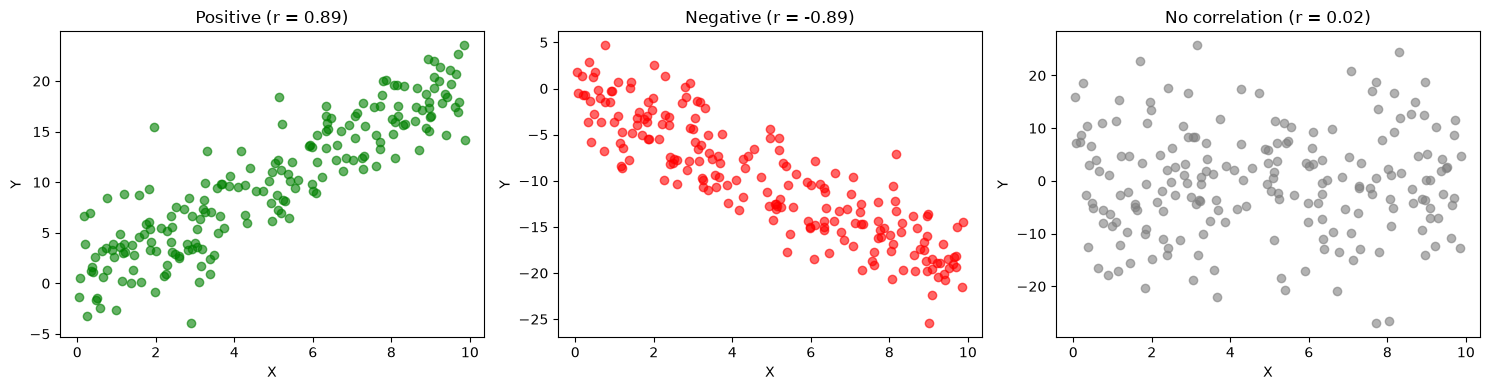

In [4]:
n = 200
x = np.random.uniform(0, 10, n)

y_pos = 2 * x + np.random.normal(0, 3, n)       # positive
y_neg = -2 * x + np.random.normal(0, 3, n)      # negative
y_none = np.random.normal(0, 10, n)             # no relation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y, title, color in zip(axes, [y_pos, y_neg, y_none],
                               ["Positive", "Negative", "No correlation"],
                               ["green", "red", "gray"]):
    r = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, alpha=0.6, color=color)
    ax.set_title(f"{title} (r = {r:.2f})")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
plt.tight_layout()
plt.show()

**Explanation:** We create three relationships with scatter plots and print r on each chart.

**Interpretation:** In the positive plot, points rise from left to right (r close to +1). In the negative plot, they fall (r close to -1). In the no-correlation plot, points form a cloud (r close to 0). **Always draw a scatter plot, because r alone can hide the shape of the relationship.**

## 4. Pearson Correlation

**Definition:** Pearson correlation measures the strength of the **linear** relationship between two **continuous** variables, using the actual values.

**Formula:**

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}$$

**Assumptions:** both variables are continuous, the relationship is roughly linear, no extreme outliers, and the data is roughly normal (for significance testing).

**Numerical Example:** The study hours and marks data above gives r = **0.99**.

**Business Example:** Relationship between a store's footfall and its daily sales (continuous, roughly linear).

**AI/ML Example:** Selecting numerical features that have a strong linear relationship with the target in Linear Regression.

**Limitation:** It misses non-linear relationships (for example, y = x squared can have r near 0) and is sensitive to outliers.

Pearson r for y = x^2: 0.0

Pearson r (clean data)     : 0.97
Pearson r (with 1 outlier) : -0.357


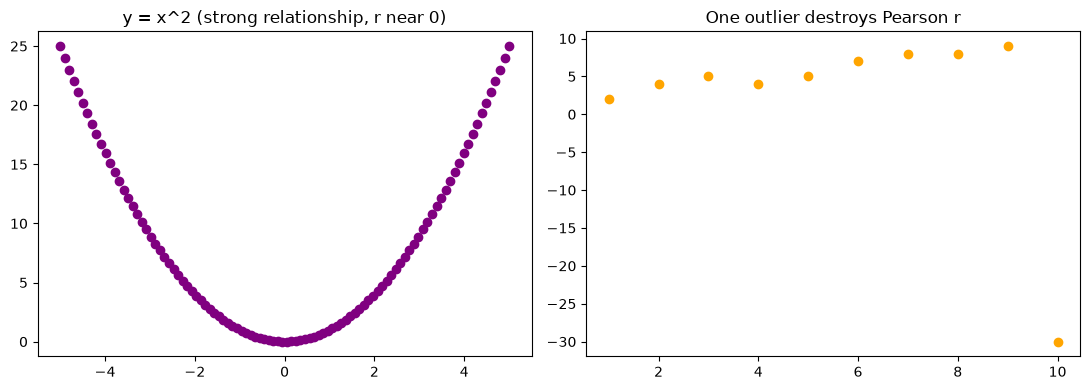

In [5]:
# Non-linear relationship
x_nl = np.linspace(-5, 5, 100)
y_nl = x_nl ** 2
print("Pearson r for y = x^2:", round(np.corrcoef(x_nl, y_nl)[0, 1], 4))

# Effect of one outlier
x1 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y1 = np.array([2, 4, 5, 4, 5, 7, 8, 8, 9, 10])
y1_out = y1.copy()
y1_out[-1] = -30     # one extreme value

print("\nPearson r (clean data)     :", round(np.corrcoef(x1, y1)[0, 1], 3))
print("Pearson r (with 1 outlier) :", round(np.corrcoef(x1, y1_out)[0, 1], 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(x_nl, y_nl, color="purple")
axes[0].set_title("y = x^2 (strong relationship, r near 0)")
axes[1].scatter(x1, y1_out, color="orange")
axes[1].set_title("One outlier destroys Pearson r")
plt.tight_layout()
plt.show()

**Explanation:** First we test a perfect but curved relationship (y = x squared). Then we change one value into an extreme outlier.

**Interpretation:** For y = x squared, Pearson r is about 0 even though y is fully determined by x, because Pearson only detects **straight-line** relationships. One outlier also changes r from strongly positive to a much lower value. This is why we plot the data and consider Spearman when relations are curved or outliers exist.

## 5. Spearman Correlation

**Definition:** Spearman correlation measures the strength of a **monotonic** relationship (one that always goes up or always goes down, not necessarily in a straight line). It converts values into **ranks** first, then applies Pearson to the ranks.

**Formula (when there are no ties):**

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

where d_i = difference between the ranks of x_i and y_i.

**Numerical Example:** Two judges rank 5 contestants.

| Contestant | Judge 1 rank | Judge 2 rank | d | d squared |
|---|---|---|---|---|
| A | 1 | 2 | -1 | 1 |
| B | 2 | 1 | 1 | 1 |
| C | 3 | 4 | -1 | 1 |
| D | 4 | 3 | 1 | 1 |
| E | 5 | 5 | 0 | 0 |

Sum of d squared = 4
rho = 1 - (6 x 4) / (5 x 24) = 1 - 0.2 = **0.8** (judges mostly agree)

**When to use:** ordinal data (ranks, ratings), non-linear but monotonic relationships, data with outliers, or non-normal data.

**Business Example:** Relationship between customer satisfaction rating (1 to 5 stars) and number of repeat purchases.

**AI/ML Example:** Feature selection when features are skewed or have outliers. Also used to compare rankings, for example a recommender system's ranking against the true ranking.

Spearman rho (judges): 0.8

Pearson  (y = x^3): 0.928
Spearman (y = x^3): 1.0

With one outlier:
Pearson  : -0.357
Spearman : 0.416


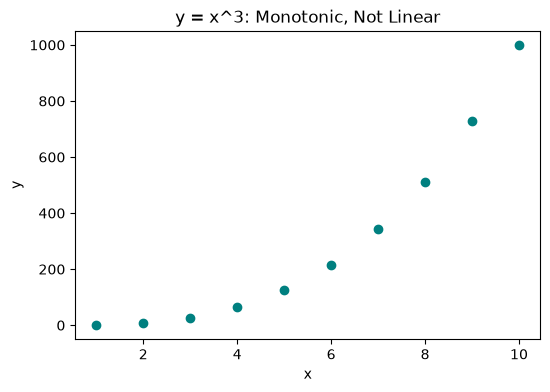

In [6]:
# Judges example
judge1 = [1, 2, 3, 4, 5]
judge2 = [2, 1, 4, 3, 5]
rho, p = stats.spearmanr(judge1, judge2)
print("Spearman rho (judges):", round(rho, 3))

# Monotonic but non-linear: y = x^3
x = np.arange(1, 11)
y = x ** 3
print("\nPearson  (y = x^3):", round(stats.pearsonr(x, y)[0], 3))
print("Spearman (y = x^3):", round(stats.spearmanr(x, y)[0], 3))

# With an outlier
print("\nWith one outlier:")
print("Pearson  :", round(np.corrcoef(x1, y1_out)[0, 1], 3))
print("Spearman :", round(stats.spearmanr(x1, y1_out)[0], 3))

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color="teal")
plt.title("y = x^3: Monotonic, Not Linear")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

**Explanation:** We calculate Spearman for the judges' ranks, then for a curved but always-increasing relationship (y = x cubed), and then for the data with an outlier, comparing each with Pearson.

**Interpretation:** For y = x cubed, Spearman is exactly **1.0** because y always increases when x increases, while Pearson is only about 0.93 because the curve is not a straight line. With an outlier, Spearman falls much less than Pearson, since ranks limit the effect of extreme values. So Spearman is **more robust** than Pearson.

| | Pearson | Spearman |
|---|---|---|
| Measures | Linear relationship | Monotonic relationship |
| Uses | Actual values | Ranks |
| Outliers | Sensitive | Robust |
| Data type | Continuous | Continuous or ordinal |

## 6. Correlation Matrix

**Definition:** A correlation matrix is a table that shows the correlation between **every pair of variables** in a dataset. The diagonal is always 1 (a variable with itself), and the matrix is symmetric.

**Formula:**

$$R_{ij} = Corr(X_i, X_j)$$

**Numerical Example:** For 3 variables A, B, C, the matrix is 3 x 3 with 1s on the diagonal. If Corr(A, B) = 0.8, then both positions (A, B) and (B, A) show 0.8.

**Business Example:** A bank checks the correlation between age, income, loan amount and credit score to understand its customers.

**AI/ML Example:** Used in **EDA** to find features correlated with the target, and to detect **multicollinearity** (features strongly correlated with each other) before training Linear or Logistic Regression.

In [7]:
n = 200
experience = np.random.uniform(0, 20, n)
age = 22 + experience + np.random.normal(0, 2, n)
salary = 25000 + 3000 * experience + np.random.normal(0, 8000, n)
screen_time = np.random.uniform(1, 8, n)
sleep_hours = 8 - 0.3 * screen_time + np.random.normal(0, 0.5, n)
random_feature = np.random.normal(0, 1, n)

df = pd.DataFrame({
    "age": age,
    "experience": experience,
    "salary": salary,
    "screen_time": screen_time,
    "sleep_hours": sleep_hours,
    "random_feature": random_feature,
})

corr_pearson = df.corr(method="pearson")
corr_spearman = df.corr(method="spearman")

print("Pearson correlation matrix:")
print(corr_pearson.round(2))

# Strongest pairs
pairs = corr_pearson.where(np.triu(np.ones(corr_pearson.shape), k=1).astype(bool)).stack()
print("\nTop pairs by absolute correlation:")
print(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(4).round(2))

Pearson correlation matrix:
                 age  experience  salary  screen_time  sleep_hours  \
age             1.00        0.95    0.87         0.08        -0.08   
experience      0.95        1.00    0.90         0.06        -0.04   
salary          0.87        0.90    1.00         0.12        -0.07   
screen_time     0.08        0.06    0.12         1.00        -0.76   
sleep_hours    -0.08       -0.04   -0.07        -0.76         1.00   
random_feature  0.03        0.03    0.03        -0.02        -0.01   

                random_feature  
age                       0.03  
experience                0.03  
salary                    0.03  
screen_time              -0.02  
sleep_hours              -0.01  
random_feature            1.00  

Top pairs by absolute correlation:
age          experience     0.95
experience   salary         0.90
age          salary         0.87
screen_time  sleep_hours   -0.76
dtype: float64


**Explanation:** We create a dataset where some features are related and some are not, then use `df.corr()` to build the matrix (Pearson and Spearman). We also list the strongest pairs using only the upper triangle, so each pair appears once.

**Interpretation:** `age` and `experience` are strongly positive (age is built from experience). `experience` and `salary` are also strongly positive. `screen_time` and `sleep_hours` are negative. `random_feature` is near 0 with everything. The diagonal is 1. Strongly correlated features such as age and experience carry the same information, which can cause **multicollinearity**.

## 7. Heatmap

**Definition:** A heatmap shows the values of a matrix as **colours**. For a correlation matrix, strong positive values look one colour (red), strong negative values another (blue), and values near 0 look neutral. It lets us spot patterns in seconds instead of reading numbers.

**Business Example:** A data analyst shares a heatmap with managers to show which business metrics move together.

**AI/ML Example:** A correlation heatmap is one of the first plots in any ML project, used to choose features and to spot highly correlated pairs.

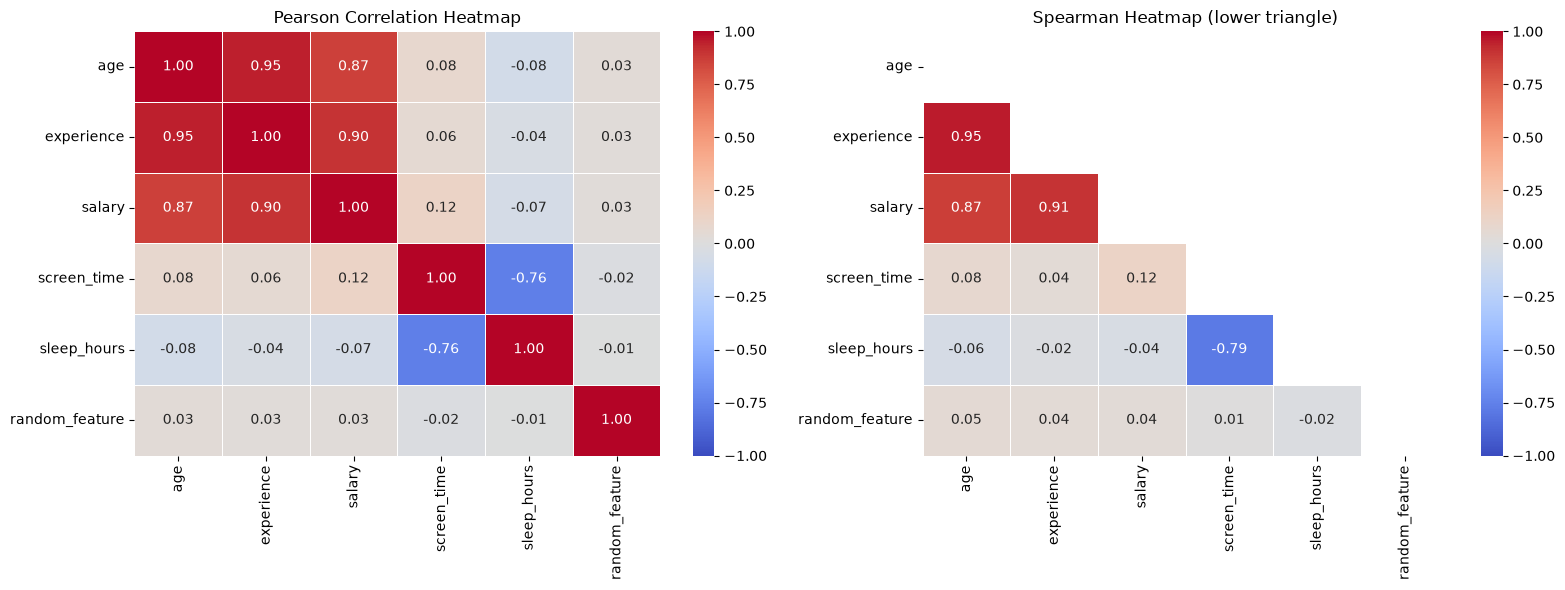

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0])
axes[0].set_title("Pearson Correlation Heatmap")

# Show only the lower triangle (removes duplicate half)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[1])
axes[1].set_title("Spearman Heatmap (lower triangle)")

plt.tight_layout()
plt.show()

**Explanation:** `sns.heatmap()` draws the matrix. `annot=True` writes the values in the cells, `cmap="coolwarm"` uses red for positive and blue for negative, and `vmin=-1, vmax=1` fixes the colour scale. The second chart hides the repeated upper half using a mask.

**Interpretation:** Dark red squares show strong positive pairs (age-experience, experience-salary). The dark blue square shows the negative pair (screen_time and sleep_hours). Pale squares show no relationship. We can see the structure of the whole dataset at once.

In [9]:
months = np.arange(12)
temperature = 20 + 12 * np.sin((months - 3) * np.pi / 6) + np.random.normal(0, 1, 12)
ice_cream = 100 + 8 * temperature + np.random.normal(0, 15, 12)
drownings = 2 + 0.3 * temperature + np.random.normal(0, 0.8, 12)

print("Corr(ice cream sales, drownings):", round(np.corrcoef(ice_cream, drownings)[0, 1], 2))
print("Corr(temperature, ice cream)    :", round(np.corrcoef(temperature, ice_cream)[0, 1], 2))
print("Corr(temperature, drownings)    :", round(np.corrcoef(temperature, drownings)[0, 1], 2))

Corr(ice cream sales, drownings): 0.94
Corr(temperature, ice cream)    : 0.98
Corr(temperature, drownings)    : 0.97


**Explanation:** Both ice cream sales and drowning cases are generated from the temperature, with no direct link between them.

**Interpretation:** Ice cream sales and drownings show a strong positive correlation, but neither causes the other. The hidden variable (**confounder**) is temperature. In ML, a model can use a correlated feature to predict well, but that does not mean the feature is the real cause, so be careful when explaining results.

## Summary

| Concept | What it tells | Range | Unit-free? |
|---|---|---|---|
| Covariance | Direction of relationship | -infinity to +infinity | No |
| Pearson correlation | Strength and direction of linear relationship | -1 to +1 | Yes |
| Spearman correlation | Strength and direction of monotonic relationship | -1 to +1 | Yes |
| Correlation matrix | Correlation of all pairs | -1 to +1 | Yes |
| Heatmap | Visual form of the matrix | - | - |

**Quick guide:**
- Linear, continuous, no outliers: **Pearson**
- Ranks, curved but monotonic, outliers, skewed: **Spearman**
- Need direction only, or input for PCA: **Covariance**

## Advantages
- Quickly shows which variables are related
- Helps select useful features and remove duplicate ones
- Correlation is unit-free, so different variables can be compared
- A heatmap shows the whole dataset's structure at a glance

## Limitations
- **Correlation does not imply causation**
- Pearson detects only linear relationships and is sensitive to outliers
- Covariance depends on units and is hard to interpret
- Correlation of 0 does not mean independence (for example, y = x squared)
- Can be misleading with small samples or with hidden confounding variables